In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
df = pd.read_excel("Medinipur.xlsx",header=1)

In [7]:
df

,State,District,Market,Commodity Group,Commodity,Date,MSP,Arrival Quantity 20-03-2021 to 20-03-2026,Arrival Unit,Min Price 20-03-2021 to 20-03-2026,Modal Price 20-03-2021 to 20-03-2026,Max Price 20-03-2021 to 20-03-2026,Price Unit
0,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Tomato,21-03-2021,-,2.0,Metric Tonnes,600.0,700.0,800.0,Rs./Quintal
1,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Tomato,22-03-2021,-,2.2,Metric Tonnes,500.0,600.0,700.0,Rs./Quintal
2,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Tomato,23-03-2021,-,2.0,Metric Tonnes,500.0,600.0,700.0,Rs./Quintal
3,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Tomato,24-03-2021,-,1.8,Metric Tonnes,800.0,900.0,1000.0,Rs./Quintal
4,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Tomato,25-03-2021,-,2.0,Metric Tonnes,500.0,600.0,700.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6706,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,19-03-2026,-,30.0,Metric Tonnes,1400.0,1420.0,1450.0,Rs./Quintal
6707,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Tomato,19-03-2026,-,2.5,Metric Tonnes,1100.0,1120.0,1150.0,Rs./Quintal
6708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6709,Note:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_onion = df[df['Commodity'] == 'Onion']

In [9]:
df_onion

,State,District,Market,Commodity Group,Commodity,Date,MSP,Arrival Quantity 20-03-2021 to 20-03-2026,Arrival Unit,Min Price 20-03-2021 to 20-03-2026,Modal Price 20-03-2021 to 20-03-2026,Max Price 20-03-2021 to 20-03-2026,Price Unit
640,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,01-11-2023,-,60.0,Metric Tonnes,4800.0,5000.0,5200.0,Rs./Quintal
642,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,02-11-2023,-,58.0,Metric Tonnes,4800.0,5100.0,5200.0,Rs./Quintal
644,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,03-11-2023,-,52.0,Metric Tonnes,5000.0,5100.0,5400.0,Rs./Quintal
646,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,04-11-2023,-,60.0,Metric Tonnes,5000.0,5100.0,5400.0,Rs./Quintal
648,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,06-11-2023,-,50.0,Metric Tonnes,5000.0,5150.0,5400.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6698,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,14-03-2026,-,25.0,Metric Tonnes,1500.0,1550.0,1600.0,Rs./Quintal
6700,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,16-03-2026,-,25.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal
6702,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,17-03-2026,-,20.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal
6704,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,18-03-2026,-,25.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal


In [10]:
df_onion.describe()

,Arrival Quantity 20-03-2021 to 20-03-2026,Min Price 20-03-2021 to 20-03-2026,Modal Price 20-03-2021 to 20-03-2026,Max Price 20-03-2021 to 20-03-2026
count,3340.000000,3340.000000,3340.000000,3340.000000
mean,9.993060,2324.636527,2450.184132,2564.729042
std,7.810618,915.974286,941.170768,979.866707
min,1.200000,1000.000000,1150.000000,1200.000000
25%,3.400000,1600.000000,1700.000000,1800.000000
50%,7.000000,2000.000000,2175.000000,2250.000000
75%,14.600000,2800.000000,2950.000000,3100.000000
max,60.000000,5200.000000,5300.000000,5500.000000


In [11]:
df_onion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3340 entries, 640 to 6706
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   State                                      3340 non-null   object 
 1   District                                   3340 non-null   object 
 2   Market                                     3340 non-null   object 
 3   Commodity Group                            3340 non-null   object 
 4   Commodity                                  3340 non-null   object 
 5   Date                                       3340 non-null   object 
 6   MSP                                        3340 non-null   object 
 7   Arrival Quantity 20-03-2021 to 20-03-2026  3340 non-null   float64
 8   Arrival Unit                               3340 non-null   object 
 9   Min Price 20-03-2021 to 20-03-2026         3340 non-null   float64
 10  Modal Price 20-03-2021 to 2

In [12]:
df_onion = df_onion.drop(columns=["MSP"])

In [13]:
df_onion

,State,District,Market,Commodity Group,Commodity,Date,Arrival Quantity 20-03-2021 to 20-03-2026,Arrival Unit,Min Price 20-03-2021 to 20-03-2026,Modal Price 20-03-2021 to 20-03-2026,Max Price 20-03-2021 to 20-03-2026,Price Unit
640,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,01-11-2023,60.0,Metric Tonnes,4800.0,5000.0,5200.0,Rs./Quintal
642,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,02-11-2023,58.0,Metric Tonnes,4800.0,5100.0,5200.0,Rs./Quintal
644,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,03-11-2023,52.0,Metric Tonnes,5000.0,5100.0,5400.0,Rs./Quintal
646,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,04-11-2023,60.0,Metric Tonnes,5000.0,5100.0,5400.0,Rs./Quintal
648,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,06-11-2023,50.0,Metric Tonnes,5000.0,5150.0,5400.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...,...,...,...
6698,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,14-03-2026,25.0,Metric Tonnes,1500.0,1550.0,1600.0,Rs./Quintal
6700,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,16-03-2026,25.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal
6702,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,17-03-2026,20.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal
6704,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,18-03-2026,25.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal


In [14]:
df_onion = df_onion.reset_index(drop=True)

In [15]:
df_onion

,State,District,Market,Commodity Group,Commodity,Date,Arrival Quantity 20-03-2021 to 20-03-2026,Arrival Unit,Min Price 20-03-2021 to 20-03-2026,Modal Price 20-03-2021 to 20-03-2026,Max Price 20-03-2021 to 20-03-2026,Price Unit
0,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,01-11-2023,60.0,Metric Tonnes,4800.0,5000.0,5200.0,Rs./Quintal
1,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,02-11-2023,58.0,Metric Tonnes,4800.0,5100.0,5200.0,Rs./Quintal
2,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,03-11-2023,52.0,Metric Tonnes,5000.0,5100.0,5400.0,Rs./Quintal
3,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,04-11-2023,60.0,Metric Tonnes,5000.0,5100.0,5400.0,Rs./Quintal
4,West Bengal,Medinipur(W),Garbeta(Medinipur) APMC,Vegetables,Onion,06-11-2023,50.0,Metric Tonnes,5000.0,5150.0,5400.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...,...,...,...
3335,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,14-03-2026,25.0,Metric Tonnes,1500.0,1550.0,1600.0,Rs./Quintal
3336,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,16-03-2026,25.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal
3337,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,17-03-2026,20.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal
3338,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,18-03-2026,25.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal


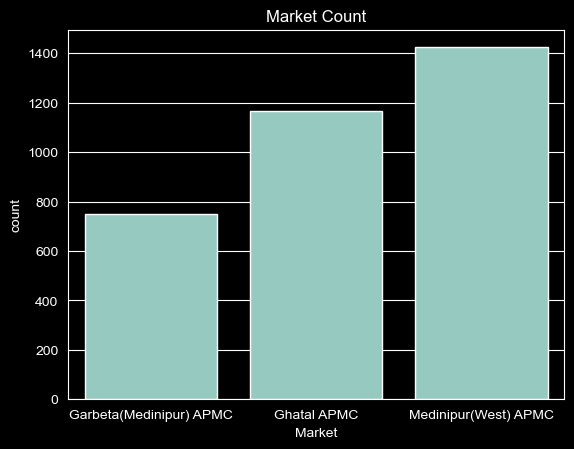

In [17]:
sns.countplot(x=df_onion["Market"])
plt.title("Market Count")
plt.show()

In [18]:
df_onion_med = df_onion[df_onion['Market'] == 'Medinipur(West) APMC'].copy()
df_onion_med = df_onion_med.reset_index(drop=True)
print(df_onion_med.shape)

(1424, 12)


In [19]:
df_onion_med

,State,District,Market,Commodity Group,Commodity,Date,Arrival Quantity 20-03-2021 to 20-03-2026,Arrival Unit,Min Price 20-03-2021 to 20-03-2026,Modal Price 20-03-2021 to 20-03-2026,Max Price 20-03-2021 to 20-03-2026,Price Unit
0,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,20-03-2021,16.0,Metric Tonnes,2000.0,2400.0,2600.0,Rs./Quintal
1,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,21-03-2021,15.0,Metric Tonnes,2000.0,2400.0,2500.0,Rs./Quintal
2,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,22-03-2021,15.0,Metric Tonnes,2000.0,2400.0,2500.0,Rs./Quintal
3,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,23-03-2021,16.0,Metric Tonnes,1900.0,2100.0,2400.0,Rs./Quintal
4,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,24-03-2021,14.0,Metric Tonnes,2000.0,2200.0,2300.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...,...,...,...
1419,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,14-03-2026,25.0,Metric Tonnes,1500.0,1550.0,1600.0,Rs./Quintal
1420,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,16-03-2026,25.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal
1421,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,17-03-2026,20.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal
1422,West Bengal,Medinipur(W),Medinipur(West) APMC,Vegetables,Onion,18-03-2026,25.0,Metric Tonnes,1400.0,1450.0,1500.0,Rs./Quintal


In [20]:
df_onion_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424 entries, 0 to 1423
Data columns (total 12 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   State                                      1424 non-null   object 
 1   District                                   1424 non-null   object 
 2   Market                                     1424 non-null   object 
 3   Commodity Group                            1424 non-null   object 
 4   Commodity                                  1424 non-null   object 
 5   Date                                       1424 non-null   object 
 6   Arrival Quantity 20-03-2021 to 20-03-2026  1424 non-null   float64
 7   Arrival Unit                               1424 non-null   object 
 8   Min Price 20-03-2021 to 20-03-2026         1424 non-null   float64
 9   Modal Price 20-03-2021 to 20-03-2026       1424 non-null   float64
 10  Max Price 20-03-2021 to 

In [21]:
df_onion_med_renewed = df_onion_med.copy()

In [22]:
df_onion_med_renewed = df_onion_med[['Date', 'Arrival Quantity 20-03-2021 to 20-03-2026', 'Min Price 20-03-2021 to 20-03-2026', 'Modal Price 20-03-2021 to 20-03-2026', 'Max Price 20-03-2021 to 20-03-2026']]

In [23]:
df_onion_med_renewed

,Date,Arrival Quantity 20-03-2021 to 20-03-2026,Min Price 20-03-2021 to 20-03-2026,Modal Price 20-03-2021 to 20-03-2026,Max Price 20-03-2021 to 20-03-2026
0,20-03-2021,16.0,2000.0,2400.0,2600.0
1,21-03-2021,15.0,2000.0,2400.0,2500.0
2,22-03-2021,15.0,2000.0,2400.0,2500.0
3,23-03-2021,16.0,1900.0,2100.0,2400.0
4,24-03-2021,14.0,2000.0,2200.0,2300.0
...,...,...,...,...,...
1419,14-03-2026,25.0,1500.0,1550.0,1600.0
1420,16-03-2026,25.0,1400.0,1450.0,1500.0
1421,17-03-2026,20.0,1400.0,1450.0,1500.0
1422,18-03-2026,25.0,1400.0,1450.0,1500.0


In [24]:
df_onion_med_renewed.columns = ["Date","Avg_Quantity", "Min_Price", "Modal_Price", "Max_Price"]

In [25]:
df_onion_med_renewed

,Date,Avg_Quantity,Min_Price,Modal_Price,Max_Price
0,20-03-2021,16.0,2000.0,2400.0,2600.0
1,21-03-2021,15.0,2000.0,2400.0,2500.0
2,22-03-2021,15.0,2000.0,2400.0,2500.0
3,23-03-2021,16.0,1900.0,2100.0,2400.0
4,24-03-2021,14.0,2000.0,2200.0,2300.0
...,...,...,...,...,...
1419,14-03-2026,25.0,1500.0,1550.0,1600.0
1420,16-03-2026,25.0,1400.0,1450.0,1500.0
1421,17-03-2026,20.0,1400.0,1450.0,1500.0
1422,18-03-2026,25.0,1400.0,1450.0,1500.0


In [26]:
df_onion_med_renewed['Date'] = pd.to_datetime(df_onion_med_renewed['Date'], format='%d-%m-%Y')

C:\Users\Arup sarkar\AppData\Local\Temp\ipykernel_31004\2403934119.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_onion_med_renewed['Date'] = pd.to_datetime(df_onion_med_renewed['Date'], format='%d-%m-%Y')


In [27]:
df_onion_med_renewed

,Date,Avg_Quantity,Min_Price,Modal_Price,Max_Price
0,2021-03-20,16.0,2000.0,2400.0,2600.0
1,2021-03-21,15.0,2000.0,2400.0,2500.0
2,2021-03-22,15.0,2000.0,2400.0,2500.0
3,2021-03-23,16.0,1900.0,2100.0,2400.0
4,2021-03-24,14.0,2000.0,2200.0,2300.0
...,...,...,...,...,...
1419,2026-03-14,25.0,1500.0,1550.0,1600.0
1420,2026-03-16,25.0,1400.0,1450.0,1500.0
1421,2026-03-17,20.0,1400.0,1450.0,1500.0
1422,2026-03-18,25.0,1400.0,1450.0,1500.0


In [28]:
df_onion_med_renewed = df_onion_med_renewed.set_index('Date')

In [29]:
df_onion_med_renewed

,Avg_Quantity,Min_Price,Modal_Price,Max_Price
Date,,,,
2021-03-20,16.0,2000.0,2400.0,2600.0
2021-03-21,15.0,2000.0,2400.0,2500.0
2021-03-22,15.0,2000.0,2400.0,2500.0
2021-03-23,16.0,1900.0,2100.0,2400.0
2021-03-24,14.0,2000.0,2200.0,2300.0
...,...,...,...,...
2026-03-14,25.0,1500.0,1550.0,1600.0
2026-03-16,25.0,1400.0,1450.0,1500.0
2026-03-17,20.0,1400.0,1450.0,1500.0


In [31]:
df_onion_med_renewed = df_onion_med_renewed.sort_index()

print("Start date:", df_onion_med_renewed.index.min())
print("End date:", df_onion_med_renewed.index.max())
print("Total days covered:", (df_onion_med_renewed.index.max() - df_onion_med_renewed.index.min()).days)
print("Total data points:", len(df_onion_med_renewed))

Start date: 2021-03-20 00:00:00
End date: 2026-03-19 00:00:00
Total days covered: 1825
Total data points: 1424


In [32]:
df_weekly = df_onion_med_renewed['Modal_Price'].resample('W').mean()

print(df_weekly.head(10))
print()
print("Total weekly points:", len(df_weekly))

Date
2021-03-21    2400.000000
2021-03-28    2180.000000
2021-04-04    1650.000000
2021-04-11    1950.000000
2021-04-18    1800.000000
2021-04-25    1714.285714
2021-05-02    1966.666667
2021-05-09    1980.000000
2021-05-16    1750.000000
2021-05-23            NaN
Freq: W-SUN, Name: Modal_Price, dtype: float64

Total weekly points: 262


In [33]:
df_weekly

Date
2021-03-21    2400.000000
2021-03-28    2180.000000
2021-04-04    1650.000000
2021-04-11    1950.000000
2021-04-18    1800.000000
                 ...     
2026-02-22    1677.142857
2026-03-01    1666.666667
2026-03-08    1550.000000
2026-03-15    1525.000000
2026-03-22    1442.500000
Freq: W-SUN, Name: Modal_Price, Length: 262, dtype: float64

In [34]:
df_weekly = df_weekly.ffill()

print(df_weekly.head(10))
print()
print("Any nulls remaining:", df_weekly.isnull().sum())

Date
2021-03-21    2400.000000
2021-03-28    2180.000000
2021-04-04    1650.000000
2021-04-11    1950.000000
2021-04-18    1800.000000
2021-04-25    1714.285714
2021-05-02    1966.666667
2021-05-09    1980.000000
2021-05-16    1750.000000
2021-05-23    1750.000000
Freq: W-SUN, Name: Modal_Price, dtype: float64

Any nulls remaining: 0


In [35]:
df_weekly

Date
2021-03-21    2400.000000
2021-03-28    2180.000000
2021-04-04    1650.000000
2021-04-11    1950.000000
2021-04-18    1800.000000
                 ...     
2026-02-22    1677.142857
2026-03-01    1666.666667
2026-03-08    1550.000000
2026-03-15    1525.000000
2026-03-22    1442.500000
Freq: W-SUN, Name: Modal_Price, Length: 262, dtype: float64

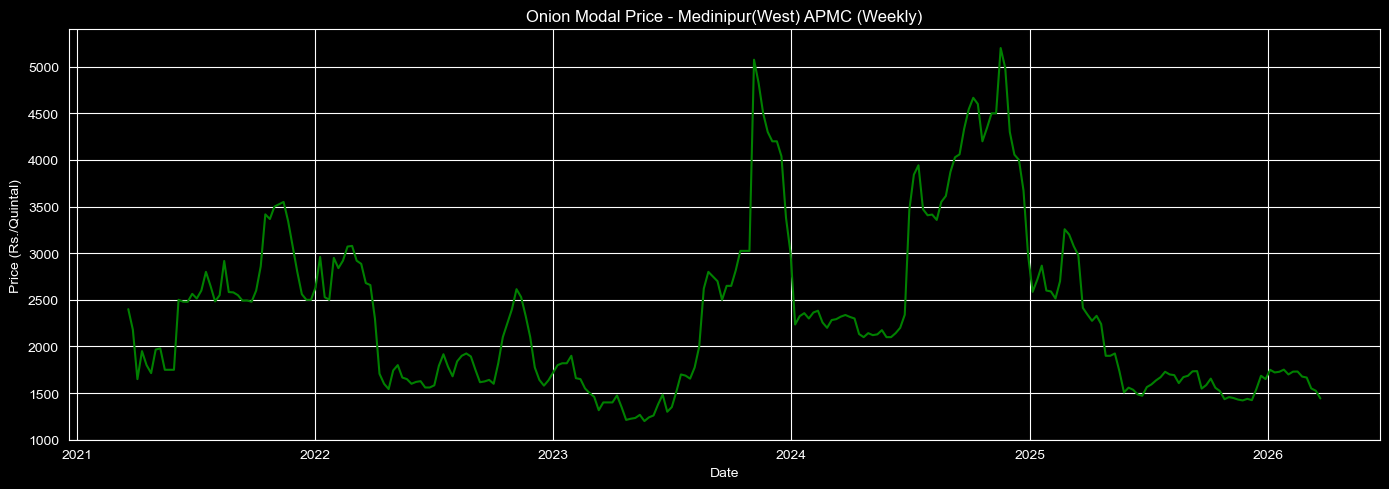

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_weekly, color='green')
plt.title('Onion Modal Price - Medinipur(West) APMC (Weekly)')
plt.xlabel('Date')
plt.ylabel('Price (Rs./Quintal)')
plt.grid(True)
plt.tight_layout()
plt.show()

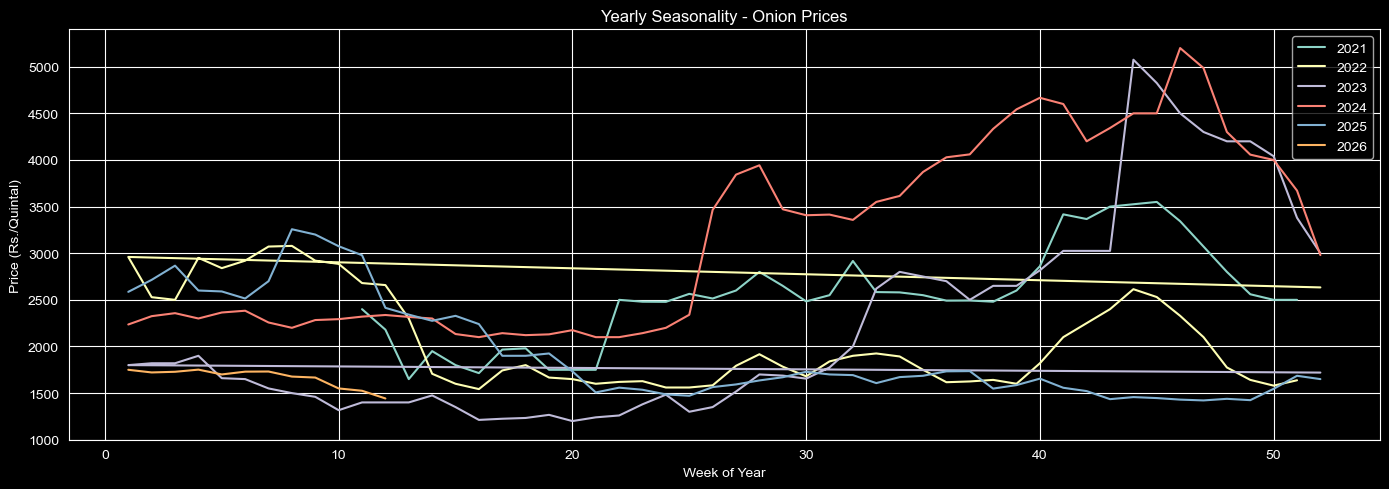

In [37]:
df_weekly_df = df_weekly.reset_index()
df_weekly_df['Year'] = df_weekly_df['Date'].dt.year
df_weekly_df['Week'] = df_weekly_df['Date'].dt.isocalendar().week.astype(int)

plt.figure(figsize=(14, 5))
for year in df_weekly_df['Year'].unique():
    yearly = df_weekly_df[df_weekly_df['Year'] == year]
    plt.plot(yearly['Week'], yearly['Modal_Price'], label=str(year))

plt.title('Yearly Seasonality - Onion Prices')
plt.xlabel('Week of Year')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
df_weekly_df

,Date,Modal_Price,Year,Week
0,2021-03-21,2400.000000,2021,11
1,2021-03-28,2180.000000,2021,12
2,2021-04-04,1650.000000,2021,13
3,2021-04-11,1950.000000,2021,14
4,2021-04-18,1800.000000,2021,15
...,...,...,...,...
257,2026-02-22,1677.142857,2026,8
258,2026-03-01,1666.666667,2026,9
259,2026-03-08,1550.000000,2026,10
260,2026-03-15,1525.000000,2026,11


In [41]:
df_prophet = df_weekly.reset_index()
df_prophet.columns = ['ds', 'y']

In [42]:
df_prophet

,ds,y
0,2021-03-21,2400.000000
1,2021-03-28,2180.000000
2,2021-04-04,1650.000000
3,2021-04-11,1950.000000
4,2021-04-18,1800.000000
...,...,...
257,2026-02-22,1677.142857
258,2026-03-01,1666.666667
259,2026-03-08,1550.000000
260,2026-03-15,1525.000000


In [43]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

14:43:37 - cmdstanpy - INFO - Chain [1] start processing
14:43:38 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
future = model.make_future_dataframe(periods=52, freq='W')

print("Future dataframe shape:", future.shape)
print("Last 5 rows:")
print(future.tail())

Future dataframe shape: (314, 1)
Last 5 rows:
            ds
309 2027-02-21
310 2027-02-28
311 2027-03-07
312 2027-03-14
313 2027-03-21


In [46]:
forecast = model.predict(future)

print(forecast.shape)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

(314, 16)
            ds        yhat   yhat_lower  yhat_upper
304 2027-01-17 -383.081139  -992.668158  299.870870
305 2027-01-24 -383.158252 -1021.979901  267.249134
306 2027-01-31 -400.253944 -1072.342827  258.351575
307 2027-02-07 -433.310229 -1087.416197  256.309043
308 2027-02-14 -447.989708 -1089.397379  199.543508
309 2027-02-21 -431.756183 -1085.083025  217.200892
310 2027-02-28 -419.679832 -1066.546935  299.799062
311 2027-03-07 -464.687723 -1119.122770  223.141850
312 2027-03-14 -591.902552 -1197.359857  118.288649
313 2027-03-21 -785.104336 -1419.231619  -88.905701


In [47]:
import numpy as np

df_prophet_log = df_prophet.copy()
df_prophet_log['y'] = np.log(df_prophet['y'])

model2 = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model2.fit(df_prophet_log)

future2 = model2.make_future_dataframe(periods=52, freq='W')
forecast2 = model2.predict(future2)

forecast2['yhat'] = np.exp(forecast2['yhat'])
forecast2['yhat_lower'] = np.exp(forecast2['yhat_lower'])
forecast2['yhat_upper'] = np.exp(forecast2['yhat_upper'])

print(forecast2[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

14:49:21 - cmdstanpy - INFO - Chain [1] start processing
14:49:21 - cmdstanpy - INFO - Chain [1] done processing


            ds        yhat  yhat_lower  yhat_upper
304 2027-01-17  656.518826  488.955951  853.358799
305 2027-01-24  651.713574  488.531238  861.897097
306 2027-01-31  644.080315  488.563259  858.888811
307 2027-02-07  635.262997  470.657697  838.852755
308 2027-02-14  629.897916  468.747222  823.397356
309 2027-02-21  627.388479  456.577249  838.768545
310 2027-02-28  621.066044  442.531415  818.919838
311 2027-03-07  604.267879  440.077024  814.127393
312 2027-03-14  575.096682  413.021368  773.438433
313 2027-03-21  535.483119  382.229358  723.992693


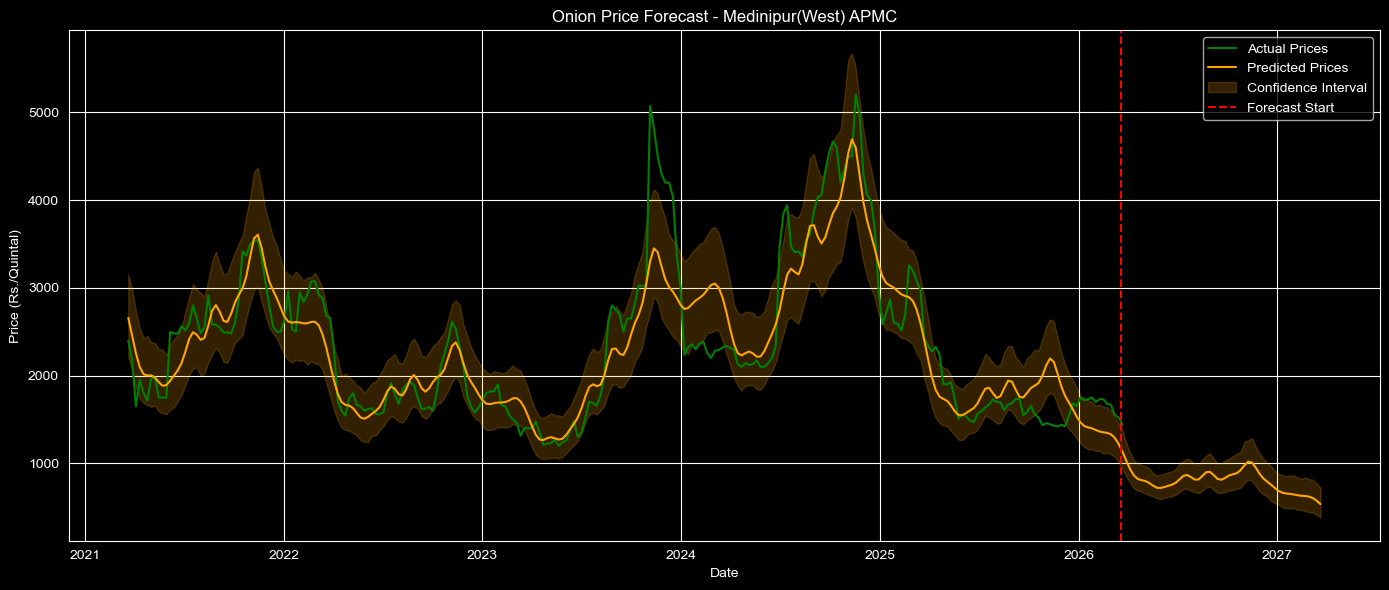

In [48]:
plt.figure(figsize=(14, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], color='green', label='Actual Prices')
plt.plot(forecast2['ds'], forecast2['yhat'], color='orange', label='Predicted Prices')
plt.fill_between(forecast2['ds'], forecast2['yhat_lower'], forecast2['yhat_upper'], color='orange', alpha=0.2, label='Confidence Interval')
plt.axvline(pd.Timestamp('2026-03-19'), color='red', linestyle='--', label='Forecast Start')
plt.title('Onion Price Forecast - Medinipur(West) APMC')
plt.xlabel('Date')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

14:53:53 - cmdstanpy - INFO - Chain [1] start processing
14:53:53 - cmdstanpy - INFO - Chain [1] done processing


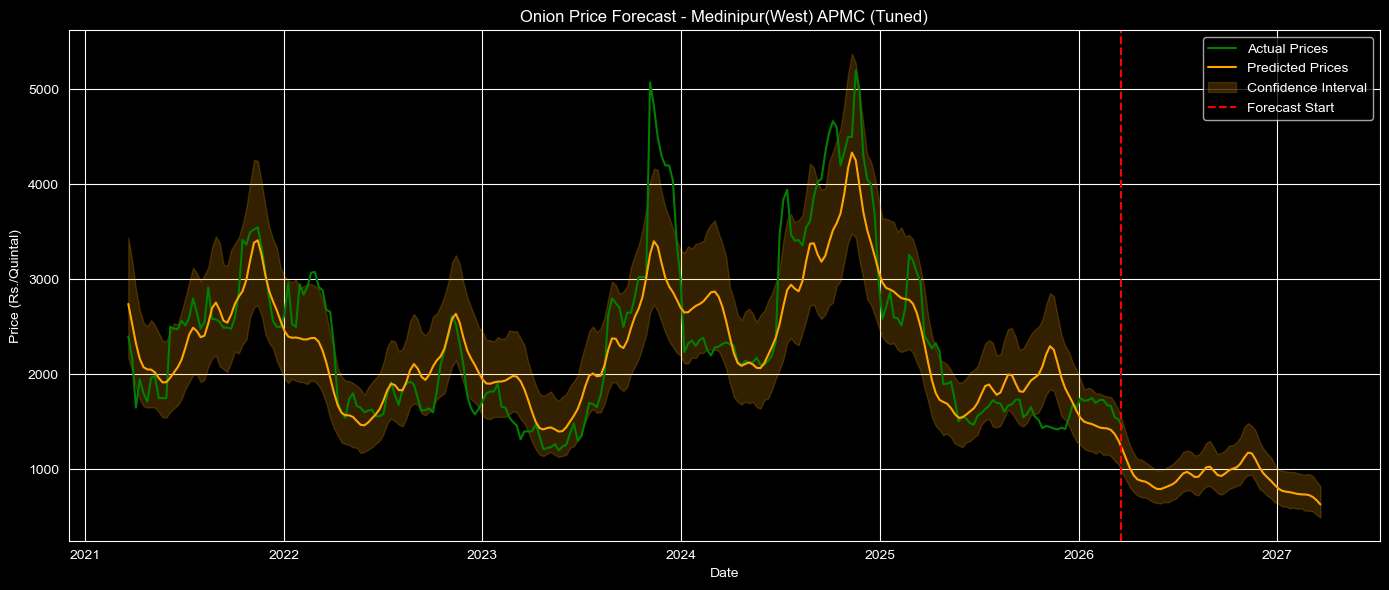

In [49]:
model3 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.01
)
model3.fit(df_prophet_log)

future3 = model3.make_future_dataframe(periods=52, freq='W')
forecast3 = model3.predict(future3)

forecast3['yhat'] = np.exp(forecast3['yhat'])
forecast3['yhat_lower'] = np.exp(forecast3['yhat_lower'])
forecast3['yhat_upper'] = np.exp(forecast3['yhat_upper'])

plt.figure(figsize=(14, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], color='green', label='Actual Prices')
plt.plot(forecast3['ds'], forecast3['yhat'], color='orange', label='Predicted Prices')
plt.fill_between(forecast3['ds'], forecast3['yhat_lower'], forecast3['yhat_upper'], color='orange', alpha=0.2, label='Confidence Interval')
plt.axvline(pd.Timestamp('2026-03-19'), color='red', linestyle='--', label='Forecast Start')
plt.title('Onion Price Forecast - Medinipur(West) APMC (Tuned)')
plt.xlabel('Date')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

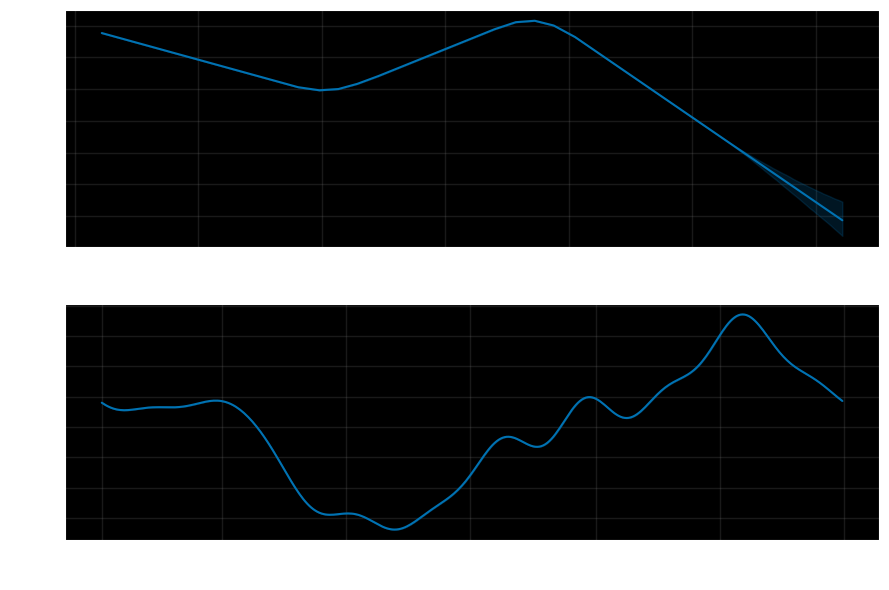

In [50]:
fig = model3.plot_components(forecast3)
plt.show()

14:58:48 - cmdstanpy - INFO - Chain [1] start processing
14:58:48 - cmdstanpy - INFO - Chain [1] done processing


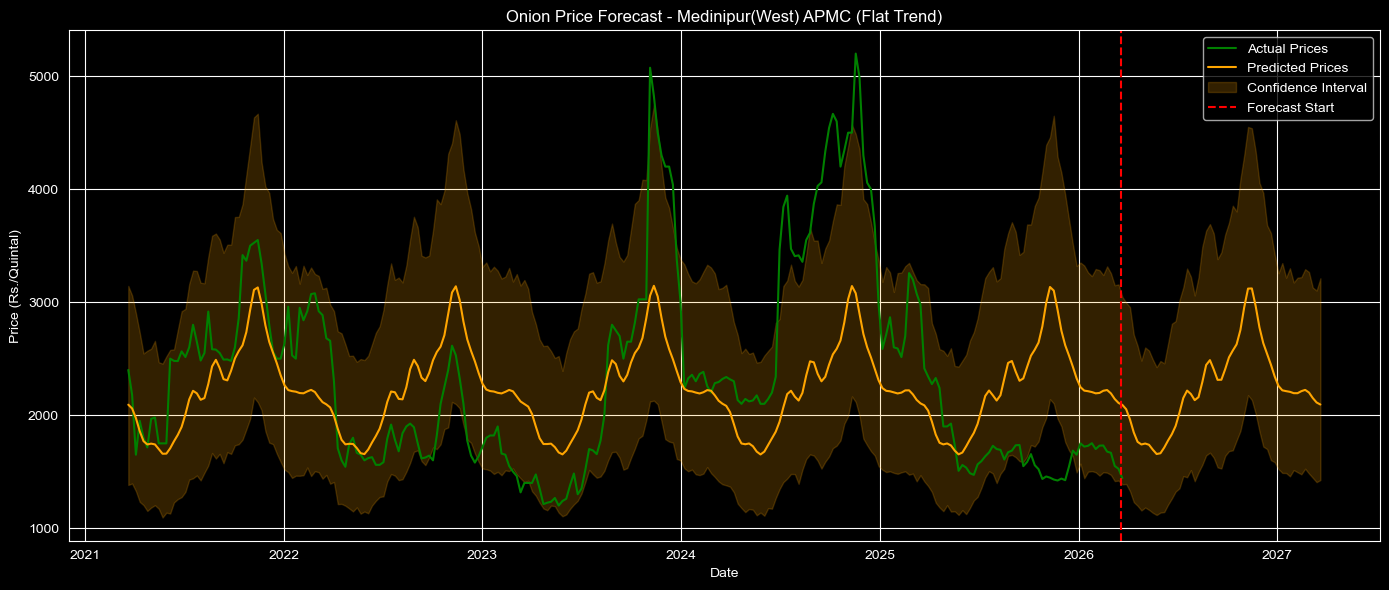

In [51]:
model4 = Prophet(
    growth='flat',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model4.fit(df_prophet_log)

future4 = model4.make_future_dataframe(periods=52, freq='W')
forecast4 = model4.predict(future4)

forecast4['yhat'] = np.exp(forecast4['yhat'])
forecast4['yhat_lower'] = np.exp(forecast4['yhat_lower'])
forecast4['yhat_upper'] = np.exp(forecast4['yhat_upper'])

plt.figure(figsize=(14, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], color='green', label='Actual Prices')
plt.plot(forecast4['ds'], forecast4['yhat'], color='orange', label='Predicted Prices')
plt.fill_between(forecast4['ds'], forecast4['yhat_lower'], forecast4['yhat_upper'], color='orange', alpha=0.2, label='Confidence Interval')
plt.axvline(pd.Timestamp('2026-03-19'), color='red', linestyle='--', label='Forecast Start')
plt.title('Onion Price Forecast - Medinipur(West) APMC (Flat Trend)')
plt.xlabel('Date')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
actual = df_prophet['y'].values
predicted = forecast4['yhat'][:len(df_prophet)].values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


MAE  : 613.52
RMSE : 778.19
MAPE : 26.72%


In [55]:
df_prophet.to_csv('onion_medinipur.csv', index=False)